# D1Q3 Lattice Boltzmann fluid (1D)

A minimal 1D LBM solver used to validate the building blocks before moving to a 2D solver with multiple chemical species.

## The model

We use the **D1Q3** lattice: 1 spatial dimension, 3 discrete velocities

$$ c_0 = 0,\quad c_1 = +1,\quad c_2 = -1 $$

with weights $w_0 = 2/3$, $w_1 = w_2 = 1/6$ and lattice sound speed $c_s^2 = 1/3$ (in lattice units, $\Delta x = \Delta t = 1$).

The state is the set of distribution functions $f_i(x, t)$. Each timestep is **collide** then **stream**:

1. **Collision** (BGK relaxation toward equilibrium):
   $$ f_i^*(x, t) = f_i(x, t) - \frac{1}{\tau}\bigl(f_i(x, t) - f_i^{\text{eq}}(x, t)\bigr) $$
2. **Streaming** (advect along discrete velocities):
   $$ f_i(x + c_i, t + 1) = f_i^*(x, t) $$

Macroscopic fields are the moments of $f$:

$$ \rho = \sum_i f_i,\qquad \rho u = \sum_i c_i f_i $$

The second-order equilibrium is

$$ f_i^{\text{eq}} = w_i \rho \left[ 1 + \frac{c_i u}{c_s^2} + \frac{(c_i u)^2}{2 c_s^4} - \frac{u^2}{2 c_s^2}\right] $$

The Chapman-Enskog expansion gives a kinematic shear viscosity

$$ \nu = c_s^2\bigl(\tau - \tfrac12\bigr) $$

so $\tau > 1/2$ is required for a positive viscosity (and numerical stability).


In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)


## Core operators

A handful of small functions are all the solver needs. Distributions are stored as an array of shape `(Q, N) = (3, N)` where `N` is the number of lattice nodes.

In [2]:
# D1Q3 lattice constants
C  = np.array([0, 1, -1])           # discrete velocities
W  = np.array([2/3, 1/6, 1/6])      # weights
CS2 = 1/3                            # lattice sound speed squared


def equilibrium(rho, u):
    """Second-order Maxwell-Boltzmann equilibrium on the D1Q3 lattice.

    rho, u: shape (N,) macroscopic fields.
    returns: shape (3, N) equilibrium distributions.
    """
    cu = np.outer(C, u)                       # (3, N)
    u2 = u * u                                # (N,)
    return W[:, None] * rho[None, :] * (
        1.0
        + cu / CS2
        + 0.5 * cu * cu / (CS2 * CS2)
        - 0.5 * u2[None, :] / CS2
    )


def macroscopic(f):
    """Compute rho and u from the distribution f."""
    rho = f.sum(axis=0)
    mom = (C[:, None] * f).sum(axis=0)
    u   = mom / rho
    return rho, u


def stream(f):
    """Periodic streaming step on a 1D lattice."""
    out = np.empty_like(f)
    out[0] = f[0]
    out[1] = np.roll(f[1],  1)   # +x movers shift right
    out[2] = np.roll(f[2], -1)   # -x movers shift left
    return out


def collide_bgk(f, tau):
    """BGK collision. Returns updated f along with rho, u."""
    rho, u = macroscopic(f)
    feq = equilibrium(rho, u)
    return f - (f - feq) / tau, rho, u


def viscosity(tau):
    return CS2 * (tau - 0.5)


In [3]:
class D1Q3Sim:
    """Thin wrapper that owns f and a tau, and runs many steps."""

    def __init__(self, rho0, u0, tau):
        rho0 = np.asarray(rho0, dtype=float)
        u0   = np.asarray(u0,   dtype=float)
        assert rho0.shape == u0.shape and rho0.ndim == 1
        self.N   = rho0.size
        self.tau = float(tau)
        self.f   = equilibrium(rho0, u0)

    def step(self, n=1):
        for _ in range(n):
            self.f, _, _ = collide_bgk(self.f, self.tau)
            self.f = stream(self.f)

    @property
    def rho(self):
        return self.f.sum(axis=0)

    @property
    def u(self):
        return (C[:, None] * self.f).sum(axis=0) / self.rho


## Validation 1 - uniform equilibrium is a fixed point

If we seed the lattice with $\rho = \mathrm{const}$, $u = 0$, the state should not move at all (every distribution is at equilibrium and no gradients exist for streaming to see).


In [4]:
sim = D1Q3Sim(rho0=np.ones(64), u0=np.zeros(64), tau=1.0)
sim.step(500)
print(f"max |rho - 1| = {np.max(np.abs(sim.rho - 1)):.2e}")
print(f"max |u|       = {np.max(np.abs(sim.u)):.2e}")


max |rho - 1| = 2.22e-16
max |u|       = 0.00e+00


## Validation 2 - sound speed

Seed a right-going traveling wave of small amplitude $\varepsilon$:

$$ \rho(x, 0) = 1 + \varepsilon \cos(kx),\qquad u(x, 0) = \varepsilon c_s \cos(kx) $$

The Fourier coefficient at wavenumber $k$ has phase $\phi(t) = -c_s k t$, so the slope of $\phi$ vs $t$ gives the measured sound speed. We pick $\tau$ close to $1/2$ to make viscous damping small over the run.


measured c = 0.57734
expected   = 0.57735  (= 1/sqrt(3))
rel error  = 1.41e-05


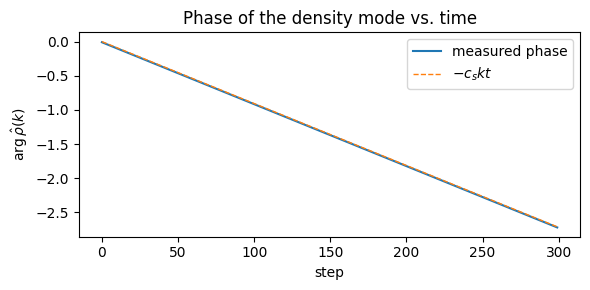

In [5]:
N   = 400
k   = 2 * np.pi / N
x   = np.arange(N)
amp = 1e-3
cs  = np.sqrt(CS2)

rho0 = 1.0 + amp * np.cos(k * x)
u0   = amp * cs * np.cos(k * x)
sim  = D1Q3Sim(rho0, u0, tau=0.51)

steps  = 300
phases = np.empty(steps)
for t in range(steps):
    sim.step()
    Fk = np.sum((sim.rho - 1.0) * np.exp(-1j * k * x))
    phases[t] = np.angle(Fk)
phases = np.unwrap(phases)

slope = np.polyfit(np.arange(steps), phases, 1)[0]
c_measured = -slope / k
print(f"measured c = {c_measured:.5f}")
print(f"expected   = {cs:.5f}  (= 1/sqrt(3))")
print(f"rel error  = {abs(c_measured - cs)/cs:.2e}")

fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(np.arange(steps), phases, lw=1.5, label='measured phase')
ax.plot(np.arange(steps), -cs * k * np.arange(steps), '--', lw=1, label=r'$-c_s k t$')
ax.set_xlabel('step')
ax.set_ylabel(r'$\arg \hat\rho(k)$')
ax.legend()
ax.set_title('Phase of the density mode vs. time')
plt.tight_layout()
plt.show()


## Validation 3 - viscous damping scales linearly with $\tau - 1/2$

Seed a standing density perturbation with $u = 0$. The mode splits into two counter-propagating sound waves whose amplitude decays exponentially at some rate $\alpha(\tau, k)$. Chapman-Enskog predicts $\alpha \propto (\tau - 1/2)\, k^2$ to leading order in $k$; the lattice introduces finite-$k$ dispersion corrections, so the proportionality holds best near $\tau = 1/2$.

We scan $\tau$, fit each exponential decay, then linear-regress $\alpha$ vs $(\tau - 1/2)$. A clean line through the origin is the validation.


tau = 0.55   alpha = 1.6569e-05   alpha / (tau - 1/2) = 3.3139e-04


tau = 0.60   alpha = 3.2535e-05   alpha / (tau - 1/2) = 3.2535e-04


tau = 0.70   alpha = 6.7426e-05   alpha / (tau - 1/2) = 3.3713e-04


tau = 0.85   alpha = 1.1521e-04   alpha / (tau - 1/2) = 3.2918e-04


tau = 1.00   alpha = 1.6633e-04   alpha / (tau - 1/2) = 3.3265e-04

linear fit: alpha = m (tau - 1/2) + b
  m = 3.3225e-04    b = -1.2572e-07


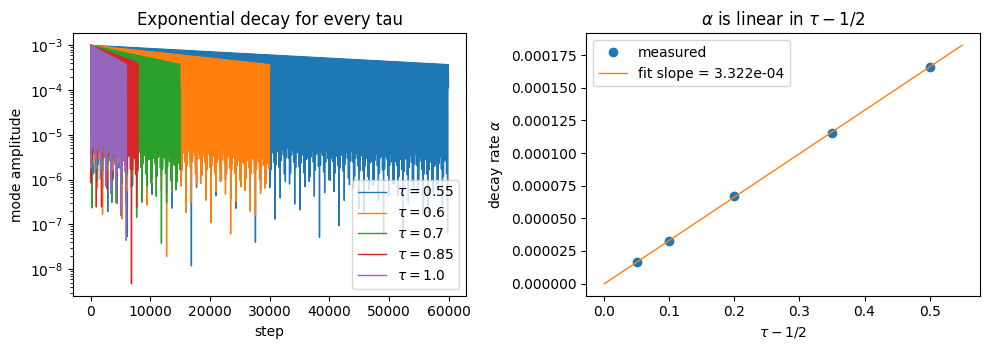

In [6]:
def measure_decay_rate(tau, N=200, steps=4000, amp=1e-3):
    k = 2 * np.pi / N
    x = np.arange(N)
    sim = D1Q3Sim(rho0=1.0 + amp * np.cos(k * x), u0=np.zeros(N), tau=tau)
    A = np.empty(steps)
    for t in range(steps):
        sim.step()
        A[t] = np.abs(np.sum((sim.rho - 1.0) * np.exp(-1j * k * x))) * 2.0 / N
    t_arr = np.arange(steps)
    mask = (t_arr > steps // 10) & (A > A[0] * 1e-4)
    slope = np.polyfit(t_arr[mask], np.log(A[mask]), 1)[0]
    return -slope, A


N = 200
taus = np.array([0.55, 0.60, 0.70, 0.85, 1.00])
# Need more steps when (tau - 1/2) is small so the mode decays enough to fit cleanly.
step_budget = {0.55: 60000, 0.60: 30000, 0.70: 15000, 0.85: 8000, 1.00: 6000}

alphas, decays = [], {}
for tau in taus:
    alpha, A = measure_decay_rate(float(tau), N=N, steps=step_budget[float(tau)])
    alphas.append(alpha)
    decays[float(tau)] = A
    print(f"tau = {tau:.2f}   alpha = {alpha:.4e}   alpha / (tau - 1/2) = {alpha/(tau-0.5):.4e}")

alphas = np.array(alphas)
slope, intercept = np.polyfit(taus - 0.5, alphas, 1)
print(f"\nlinear fit: alpha = m (tau - 1/2) + b")
print(f"  m = {slope:.4e}    b = {intercept:.4e}")

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(10, 3.6))
for tau, A in decays.items():
    ax0.semilogy(np.arange(A.size), A, lw=1, label=fr'$\tau={tau}$')
ax0.set_xlabel('step')
ax0.set_ylabel('mode amplitude')
ax0.set_title('Exponential decay for every tau')
ax0.legend()

ax1.plot(taus - 0.5, alphas, 'o', ms=6, label='measured')
xs = np.linspace(0, 0.55, 100)
ax1.plot(xs, slope * xs + intercept, '-', lw=1, label=f'fit slope = {slope:.3e}')
ax1.set_xlabel(r'$\tau - 1/2$')
ax1.set_ylabel(r'decay rate $\alpha$')
ax1.set_title(r'$\alpha$ is linear in $\tau - 1/2$')
ax1.legend()
plt.tight_layout()
plt.show()


## Demo - Gaussian density bump

A localized bump of dense fluid releases two outward-traveling sound waves. With a moderate viscosity the wavefronts visibly smear as they propagate.


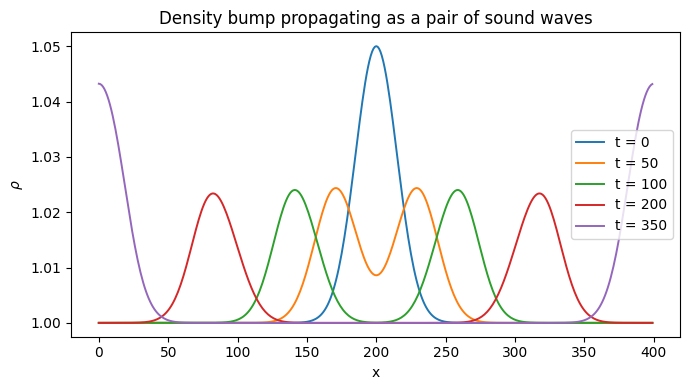

In [7]:
N   = 400
x   = np.arange(N)
rho0 = 1.0 + 0.05 * np.exp(-((x - N/2) ** 2) / (2 * 15.0 ** 2))
sim  = D1Q3Sim(rho0, np.zeros(N), tau=0.7)

snapshots = {0: sim.rho.copy()}
for target in (50, 100, 200, 350):
    sim.step(target - max(snapshots))
    snapshots[target] = sim.rho.copy()

fig, ax = plt.subplots(figsize=(7, 4))
for t, rho in snapshots.items():
    ax.plot(x, rho, lw=1.4, label=f't = {t}')
ax.set_xlabel('x')
ax.set_ylabel(r'$\rho$')
ax.set_title('Density bump propagating as a pair of sound waves')
ax.legend()
plt.tight_layout()
plt.show()


## Mass and momentum conservation

Streaming and BGK collision both conserve mass and momentum exactly (collision because $\sum_i f_i^{\text{eq}} = \rho$ and $\sum_i c_i f_i^{\text{eq}} = \rho u$, streaming because it is a pure permutation of cells on a periodic lattice). We spot-check this on the bump above; any residual is just floating-point summation error.


In [8]:
sim2 = D1Q3Sim(rho0, np.zeros(N), tau=0.7)
mass0, mom0 = sim2.rho.sum(), (sim2.rho * sim2.u).sum()
sim2.step(1000)
mass1, mom1 = sim2.rho.sum(), (sim2.rho * sim2.u).sum()
print(f"mass drift     = {mass1 - mass0:.2e}  (relative: {(mass1-mass0)/mass0:.2e})")
print(f"momentum drift = {mom1 - mom0:.2e}")


mass drift     = -3.10e-11  (relative: -7.72e-14)
momentum drift = -3.50e-15


## Next steps - toward the 2D multi-species solver

The pieces above generalize cleanly:

- **Lattice**: D1Q3 -> **D2Q9** (9 velocities). Weights become $w_0 = 4/9$, the 4 axial $w = 1/9$, the 4 diagonal $w = 1/36$, and $c_s^2$ is still $1/3$.
- **Streaming**: still a periodic shift per velocity, just along $(c_{ix}, c_{iy})$ on a 2D array.
- **Equilibrium**: identical formula with $c_i \cdot u$ as a 2-vector dot product.
- **Chemical species**: carry a passive scalar $g_i(x, t)$ on the same lattice using a separate BGK relaxation $\tau_g$ - that gives advection-diffusion of the concentration field with diffusivity $D = c_s^2(\tau_g - 1/2)$.
- **Attraction / repulsion**: a Shan-Chen style forcing term coupling species $a$ and $b$,
  $$ \mathbf F_a(\mathbf x) = -G_{ab}\, \psi_a(\mathbf x) \sum_i w_i\, \psi_b(\mathbf x + \mathbf c_i)\, \mathbf c_i, $$
  with the sign of $G_{ab}$ controlling attraction vs. repulsion. The force is folded back into the collision via a Guo or velocity-shift forcing scheme.
- **Entropy**: track $S = -\sum_i f_i \ln(f_i / w_i)$ as a diagnostic. An entropic LBM variant additionally chooses $\tau$ per step from an H-theorem condition to stay unconditionally stable at low $\nu$.

For now this 1D sandbox is enough to know the collide / stream / equilibrium kernels are wired up correctly before scaling to 2D.
